# Exploratory Data Analysis (EDA)

## importing Libraries 

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Data

In [35]:
df = pd.read_csv(r"C:\Users\shant\OneDrive\Desktop\Intern\Task5\LusitaniaManifest.csv")
df.head()

,Unnamed: 0,Family name,Title,Personal name,Fate,Age,Department/Class,Passenger/Crew,Citizenship,Position,Status,City,Lifeboat,Rescue Vessel,Adult/Minor,Sex
0,0,CAMERON,Mr.,Charles W.,Lost,38.0,Band,Crew,British,NaN,NaN,NaN,NaN,NaN,Adult,Male
1,1,CARR-JONES,Mr.,E.,Lost,37.0,Band,Crew,British,NaN,NaN,NaN,NaN,NaN,Adult,Male
2,2,DRAKEFORD,Mr.,Edward,Saved,30.0,Band,Crew,British,Violin,NaN,NaN,NaN,NaN,Adult,Male
3,3,HAWKINS,Mr.,Handel,Saved,25.0,Band,Crew,British,Cello,NaN,NaN,NaN,NaN,Adult,Male
4,4,HEMINGWAY,Mr.,John William,Saved,27.0,Band,Crew,British,Double Bass,NaN,NaN,NaN,NaN,Adult,Male


## Check for Missing Values

In [36]:
print(df.isnull().sum())

Unnamed: 0             0
Family name            0
Title                  0
Personal name          3
Fate                   0
Age                  662
Department/Class       0
Passenger/Crew         0
Citizenship            2
Position            1270
Status              1170
City                 682
Lifeboat            1867
Rescue Vessel       1810
Adult/Minor            0
Sex                    0
dtype: int64


## Data Cleaning

In [45]:
columns_to_keep = [
    'Family name', 'Title', 'Fate', 'Age',
    'Department/Class', 'Passenger/Crew',
    'Citizenship', 'City', 'Adult/Minor', 'Sex'
]

data = df[columns_to_keep]

## Check for null values

In [46]:
print(data.isnull().sum())

Family name           0
Title                 0
Fate                  0
Age                 662
Department/Class      0
Passenger/Crew        0
Citizenship           2
City                682
Adult/Minor           0
Sex                   0
dtype: int64


In [47]:
data_clean = data.dropna(subset=['Age'])

In [48]:
data.head()

,Family name,Title,Fate,Age,Department/Class,Passenger/Crew,Citizenship,City,Adult/Minor,Sex
0,CAMERON,Mr.,Lost,38.0,Band,Crew,British,NaN,Adult,Male
1,CARR-JONES,Mr.,Lost,37.0,Band,Crew,British,NaN,Adult,Male
2,DRAKEFORD,Mr.,Saved,30.0,Band,Crew,British,NaN,Adult,Male
3,HAWKINS,Mr.,Saved,25.0,Band,Crew,British,NaN,Adult,Male
4,HEMINGWAY,Mr.,Saved,27.0,Band,Crew,British,NaN,Adult,Male


## Fill missing categorical columns with placeholder if needed

In [50]:
df['City'].fillna('Unknown', inplace=True)

C:\Users\shant\AppData\Local\Temp\ipykernel_12116\1427820024.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna('Unknown', inplace=True)


## Clean categorical entries (if inconsistencies are there)

In [51]:
data['Sex'] = data['Sex'].str.capitalize()
data['Fate'] = data['Fate'].str.capitalize()
data['Passenger/Crew'] = data['Passenger/Crew'].str.capitalize()

C:\Users\shant\AppData\Local\Temp\ipykernel_12116\1729835109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sex'] = data['Sex'].str.capitalize()
C:\Users\shant\AppData\Local\Temp\ipykernel_12116\1729835109.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Fate'] = data['Fate'].str.capitalize()
C:\Users\shant\AppData\Local\Temp\ipykernel_12116\1729835109.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [52]:
data.head()

,Family name,Title,Fate,Age,Department/Class,Passenger/Crew,Citizenship,City,Adult/Minor,Sex
0,CAMERON,Mr.,Lost,38.0,Band,Crew,British,NaN,Adult,Male
1,CARR-JONES,Mr.,Lost,37.0,Band,Crew,British,NaN,Adult,Male
2,DRAKEFORD,Mr.,Saved,30.0,Band,Crew,British,NaN,Adult,Male
3,HAWKINS,Mr.,Saved,25.0,Band,Crew,British,NaN,Adult,Male
4,HEMINGWAY,Mr.,Saved,27.0,Band,Crew,British,NaN,Adult,Male


## Creating column for age group

In [53]:
data['Age Group'] = pd.cut(data['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])

C:\Users\shant\AppData\Local\Temp\ipykernel_12116\390255560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age Group'] = pd.cut(data['Age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])


In [67]:
data.head()

,Family name,Title,Fate,Age,Department/Class,Passenger/Crew,Citizenship,City,Adult/Minor,Sex,Age Group
0,CAMERON,Mr.,Lost,38.0,Band,Crew,British,NaN,Adult,Male,Adult
1,CARR-JONES,Mr.,Lost,37.0,Band,Crew,British,NaN,Adult,Male,Adult
2,DRAKEFORD,Mr.,Saved,30.0,Band,Crew,British,NaN,Adult,Male,Adult
3,HAWKINS,Mr.,Saved,25.0,Band,Crew,British,NaN,Adult,Male,Adult
4,HEMINGWAY,Mr.,Saved,27.0,Band,Crew,British,NaN,Adult,Male,Adult


# Exploratory Data Analysis

This Chart shows how ages are distributed across the population with both the histogram and the KDE curve for a smoother representation of the distribution.

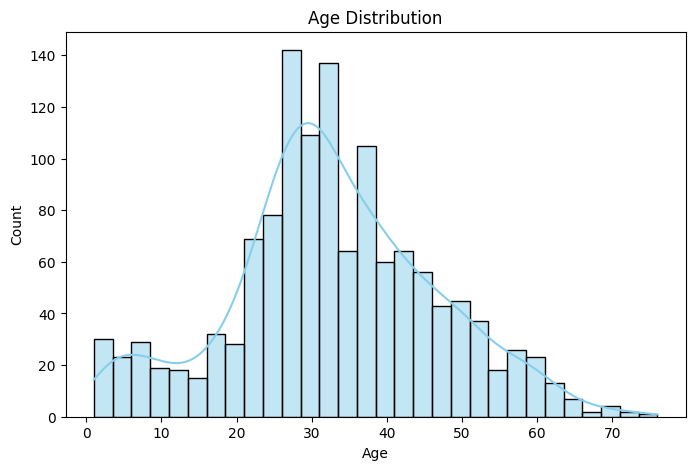

In [69]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Plot used to compare how the distribution of age differs depending on fate.

C:\Users\shant\AppData\Local\Temp\ipykernel_12116\3682361086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fate', y='Age', data=data, palette='Set2')


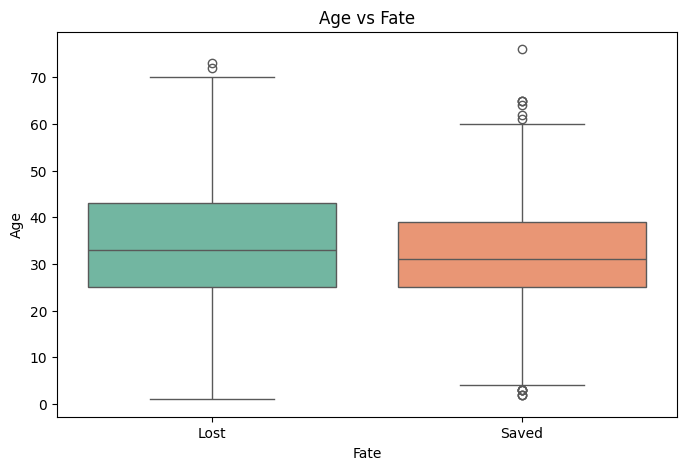

In [70]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fate', y='Age', data=data, palette='Set2')
plt.title("Age vs Fate")
plt.xlabel("Fate")
plt.ylabel("Age")
plt.show()


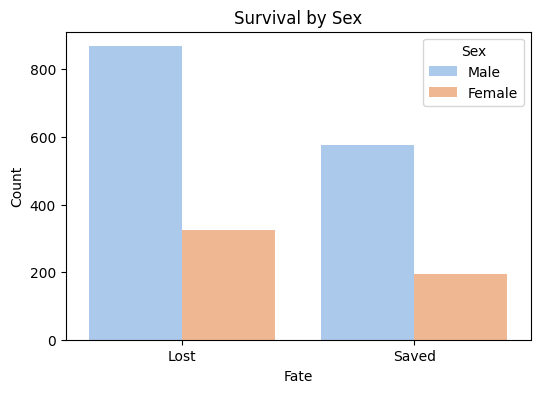

In [71]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Fate', hue='Sex', data=data, palette='pastel')
plt.title("Survival by Sex")
plt.xlabel("Fate")
plt.ylabel("Count")
plt.show()


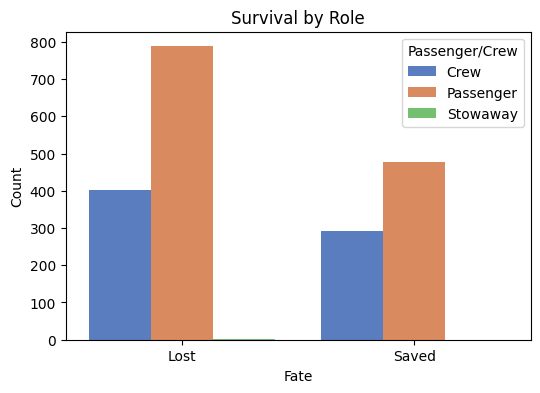

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Fate', hue='Passenger/Crew', data=data, palette='muted')
plt.title("Survival by Role")
plt.xlabel("Fate")
plt.ylabel("Count")
plt.show()


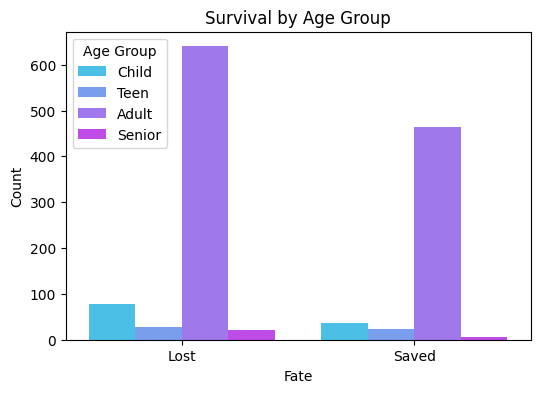

In [73]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Fate', hue='Age Group', data=data, palette='cool')
plt.title("Survival by Age Group")
plt.xlabel("Fate")
plt.ylabel("Count")
plt.show()


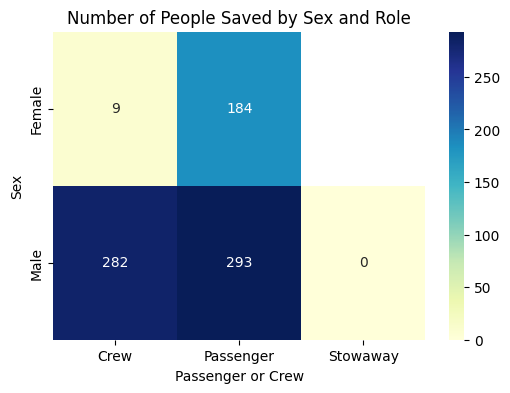

In [ ]:

heatmap_data = data.pivot_table(
    index='Sex',
    columns='Passenger/Crew',
    values='Fate',
    aggfunc=lambda x: (x == 'Saved').sum()
)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Number of People Saved by Sex and Role")
plt.ylabel("Sex")
plt.xlabel("Passenger or Crew")
plt.show()

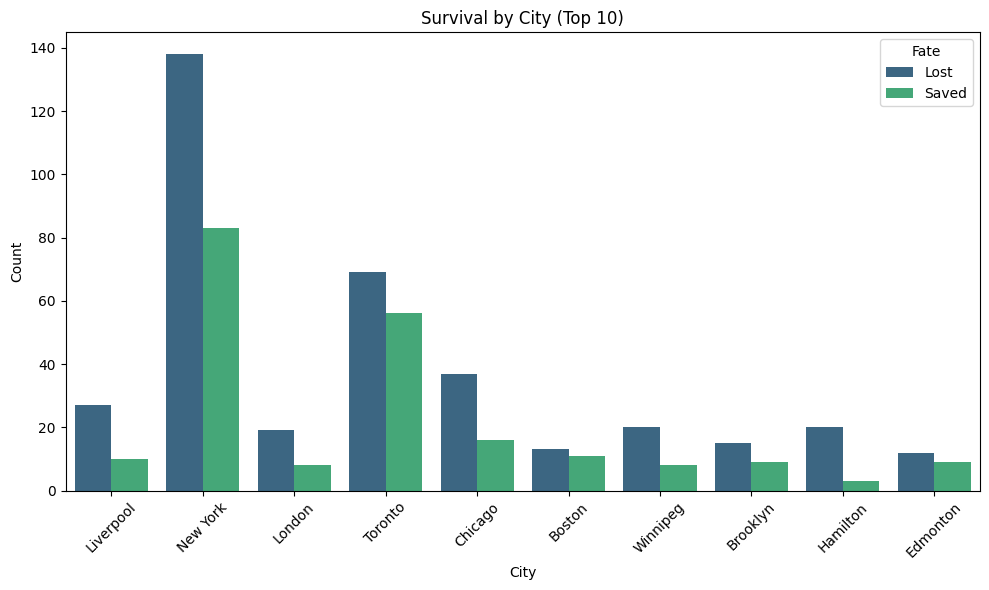

In [77]:
top_cities = data['City'].value_counts().nlargest(10).index
data_top_cities = data[data['City'].isin(top_cities)]

plt.figure(figsize=(10, 6))
sns.countplot(x='City', hue='Fate', data=data_top_cities, palette='viridis')
plt.title("Survival by City (Top 10)")
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
